In [1]:
import pandas as pd
from tqdm.auto import tqdm
import numpy as np

/home/visanim/github/sirius-ms1-vs-ms12/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path
import uuid
import sys
import gzip

# Columns we always expect
REQUIRED_COLUMNS: list[str] = [
    "inchiKey",
    "smiles",
    "xlogP",
    "rank",
    "csiScore",
    "tanimotoSimilarity",
    "mcesDistToTopHit",
    "molecularFormula",
    "adduct",
    "formulaId",
    "feature_id",
    "npc_pathway",
    "npc_superclass",
    "npc_class",
]

ANNOTATION_FILE: str = "sirius/annotation_results.csv.gz"


def get_inchi_to_csi(df):
    inchi_to_csi = dict(zip(df.inchiKey, df.csiScore))
    return inchi_to_csi


def get_inchi_to_prob(inchi_to_csi):
    inchi_to_csi_to_prob = {
        inchi: np.exp(csi, dtype=np.float128) for inchi, csi in inchi_to_csi.items()
    }
    prob_sum = sum(inchi_to_csi_to_prob.values())
    inchi_to_prob = {
        inchi: prob / prob_sum for inchi, prob in inchi_to_csi_to_prob.items()
    }
    return inchi_to_prob


def load_annotation_file(path: Path) -> pd.DataFrame | None:
    """Read a gzipped CSV; return None if missing or empty."""
    if not path.exists():
        return None
    try:
        with gzip.open(path, "rt", encoding="utf-8") as fh:
            df = pd.read_csv(fh)
        if df.empty:
            return None
        # Keep only expected columns that are actually present
        present = [c for c in REQUIRED_COLUMNS if c in df.columns]
        return df[present]
    except Exception as exc:  # noqa: BLE001
        print(f"  WARNING: could not read {path}: {exc}", file=sys.stderr)
        return None


def collect_mode_data(
    ionization_dir: Path,
    mode: str,
) -> pd.DataFrame:
    """
    Walk *ionization_dir* and concatenate every annotation CSV for *mode*.

    Adds columns ``sample`` and ``ionization`` for traceability.
    """
    frames: list[pd.DataFrame] = []
    for sample_dir in sorted(ionization_dir.iterdir()):
        if not sample_dir.is_dir():
            continue
        annotation_path = sample_dir / mode / ANNOTATION_FILE
        df = load_annotation_file(annotation_path)
        if df is None:
            continue
        df = df.copy()
        df["sample"] = sample_dir.name
        df["ionization"] = ionization_dir.name

        # we generate a uuid per feature_id
        df["unique_feature_id"] = (
            df["feature_id"].astype(str) + "_" + df["sample"] + "_" + df["ionization"]
        )
        frames.append(df)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

In [3]:
df_ms2_only = collect_mode_data(Path("positive"), "sirius_ms2_only")
df_normal = collect_mode_data(Path("positive"), "sirius_normal")

In [4]:
shared_features = sorted(
    set(df_ms2_only["unique_feature_id"]).intersection(
        set(df_normal["unique_feature_id"])
    )
)

In [5]:
from dictances import kullback_leibler

kl_divergences = []
normal_groups = df_normal.groupby("unique_feature_id")
ms2_groups = df_ms2_only.groupby("unique_feature_id")

for feature_id in tqdm(shared_features):
    normal_inchi_to_prob = get_inchi_to_prob(
        get_inchi_to_csi(normal_groups.get_group(feature_id))
    )
    ms2_only_inchi_to_prob = get_inchi_to_prob(
        get_inchi_to_csi(ms2_groups.get_group(feature_id))
    )
    # compute KL divergence here
    try:
        kl_divergence = kullback_leibler(normal_inchi_to_prob, ms2_only_inchi_to_prob)
        if np.isfinite(kl_divergence):
            kl_divergences.append(kl_divergence)
        else:
            # kl_divergences.append(10000)
            continue
    except ValueError:
        continue

100%|██████████| 10842/10842 [00:22<00:00, 473.01it/s]


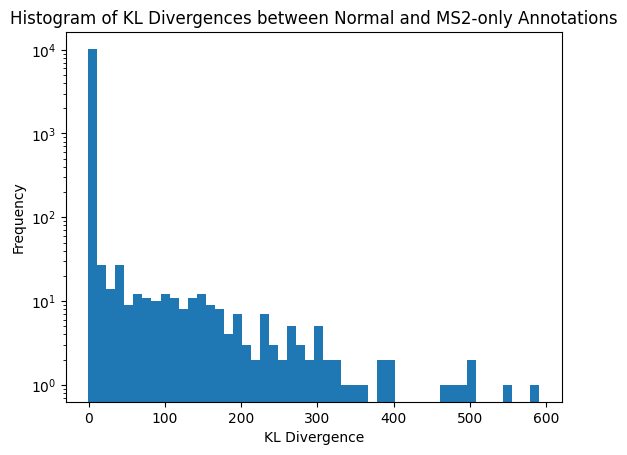

In [6]:
import matplotlib.pyplot as plt

plt.hist(kl_divergences, bins=50)
plt.xlabel("KL Divergence")
plt.ylabel("Frequency")
plt.title("Histogram of KL Divergences between Normal and MS2-only Annotations")
# log scale for better visibility
plt.yscale("log")
plt.show()

In [7]:
# for both normal and ms2-only run we create a  FxF symmetric matrix of KL divergences between the features.
# we can then plot the hist of KL divergences between all pairs of features, and see if the distribution is different for normal vs ms2-only annotations.


def build_feature_distributions(df):
    groups = df.groupby("unique_feature_id")
    dist: dict[str, dict[str, float]] = {}

    for fid, g in groups:
        csi = g["csiScore"].values.astype(np.float128)
        exp_scores = np.exp(csi)  # stable softmax
        probs = exp_scores / exp_scores.sum()
        dist[fid] = dict(zip(g["inchiKey"].values, probs))

    return dist


def compute_kl_matrix(df, shared_features: list[str]):
    kl_divergences = []
    distributions = build_feature_distributions(df)

    n = len(shared_features)

    for i in tqdm(range(n)):
        d_i = distributions[shared_features[i]]
        for j in range(i + 1, n):
            d_j = distributions[shared_features[j]]

            try:
                kl_divergences.append(kullback_leibler(d_i, d_j))
            except ValueError:
                continue

    return kl_divergences




In [ ]:
kl_matrix_normal = compute_kl_matrix(df_normal, shared_features)
kl_matrix_ms2_only = compute_kl_matrix(df_ms2_only, shared_features)

 60%|█████▉    | 6479/10842 [22:19<15:22,  4.73it/s]  